**Importing the Required Libraries**

**Data Content Overview**

The dataset consists of telemetry and sensor readings collected from Electric Truck-Mounted Forklifts (ETMFL). Each row represents a specific snapshot of the machine's operational state at a given time (TS_ROUND), labeled with any active fault codes.

The data is divided into three main categories:

1. Target Variable (The "Label")
CONTROLLER_ERROR_CODE: The categorical variable indicating the health status of the machine.

Contains specific error codes (e.g., 51, 66, 21) representing different failure modes.

Normal Operation is typically represented by code 0 (after cleaning).

Note: 
a. Raw data contained multiple errors per timestamp (e.g., "51, 56"), which were separated during preprocessing.
b. Normal operation data is represented by '51', '56', '21', '66', '64' or '65'


2. Identifiers
MACHINE_IDENTIFIER: A unique ID for the specific forklift unit.

TS_ROUND: A timestamp or round identifier indicating when the sensor snapshot was recorded.

3. Sensor Telemetry (The "Features")
The dataset contains approximately 20+ numeric sensor readings monitoring the machine's critical subsystems:

Battery System:

Voltage & Current: BATTERYARRAYVOLTAGE, BATTERYARRAYCURRENT, BATTERYLOWESTCELLVOLTAGE.

Status: BATTERYSTATEOFCHARGE (SOC %).

Drive Motors (Front-Left, Front-Right, Rear):

Performance: MOTORTORQUEFL, MOTORTORQUEFR, MOTORTORQUEREAR.

Power Consumption: MOTORPOWERFL, MOTORPOWERREAR.

Health: MOTORTEMPERATUREREAR, BATTERYCURRENTFR, BATTERYCURRENTREAR.

Hydraulic Pump System:

Operation: MOTORRPMPUMP (Speed), MOTORTORQUEPUMP (Load), STEERANGLEPUMP.

Electrical: BATTERYCURRENTPUMP, BATTERYPOWERPUMP, MOTORPOWERPUMP.

Controller: CONTROLLERTEMPERATUREPUMP (monitoring for overheating)


In [22]:
**Required Libraries**
pip install pandas numpy plotly matplotlib seaborn scikit-learn scipy imbalanced-learn dash

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import base64
import io
import sys

# Machine Learning & Stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, adjusted_rand_score
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage
from imblearn.over_sampling import SMOTE

# Dash Application
from dash import Dash, dcc, html, Input, Output, State, ALL

**DATA LOADING & PREPROCESSING**

**Data Quality Issues**

The raw ETMFL sensor data presented several challenges that required significant cleaning before modeling could begin:

Compound Error Codes: The target variable (CONTROLLER_ERROR_CODE) contained multiple errors packed into single strings (e.g., "51, 56"), making it impossible to classify individual failure modes directly.

Dirty Formatting: The error codes contained inconsistent whitespace and empty strings, leading to duplicate or invalid categories.

Missing Values: Critical rows lacked error codes entirely, and sensor readings contained NaN values that would break most machine learning algorithms.

Class Imbalance: Certain error codes appeared far more frequently than others, biasing models toward the majority classes.

High Multicollinearity: Many sensor readings (e.g., Battery Current vs. Battery Power) were highly correlated (>95%), adding redundancy and noise to the dataset.

**Data Cleaning Pipeline**

To address these issues, the following preprocessing steps were applied:

Explosion & Parsing: The CONTROLLER_ERROR_CODE column was split by commas and "exploded" into separate rows, ensuring each row represented a single, distinct failure event.

String Sanitization: All error codes were stripped of whitespace, and empty strings were removed to ensure clean, consistent labels.

Strict Filtering: Rows with missing target labels or missing sensor features were dropped to ensure data integrity (dropna).

SMOTE Balancing: Synthetic Minority Over-sampling Technique (SMOTE) was applied to generate synthetic examples for rare error codes, creating a perfectly balanced dataset for training.

Correlation Reduction: A correlation matrix was computed, and features with a correlation higher than 95% were automatically dropped to reduce dimensionality and improve model stability.

Normalization: Finally, all sensor features were standardized (StandardScaler) to a mean of 0 and variance of 1, ensuring that features with large ranges (like RPM) did not dominate the models.

In [23]:
# Importing the dataset
path = 'base data.csv'
df = pd.read_csv(path) # Load csv into a dataframe
'''
print('='*90)
print(df.head()) #visualise the first 5 rows

# Visualise data distribution and data summary
print('='*90)
print(df.describe())
'''
print('='*90)

# DATA CLEANING & EXPLOSION


# Remove rows where CONTROLLER_ERROR_CODE is Null
df = df.dropna(subset=['CONTROLLER_ERROR_CODE'])

# Define normal operating condition codes 
turn_to_zero = {'51', '56', '21', '66', '64', '65'}

print('='*90)
print("Original head:")
print(df['CONTROLLER_ERROR_CODE'].head())

#  Ensure column is string
#  Split by comma
#  Explode into individual rows
df['CONTROLLER_ERROR_CODE'] = df['CONTROLLER_ERROR_CODE'].astype(str).str.split(',')
df_exploded = df.explode('CONTROLLER_ERROR_CODE')

#  Strip whitespace (crucial for split strings like "51, 56") and remove empty strings
df_exploded['CONTROLLER_ERROR_CODE'] = df_exploded['CONTROLLER_ERROR_CODE'].str.strip()
df_exploded = df_exploded[df_exploded['CONTROLLER_ERROR_CODE'] != '']

# Overwrite normal conditions with '0'
df_exploded.loc[df_exploded['CONTROLLER_ERROR_CODE'].isin(turn_to_zero), 'CONTROLLER_ERROR_CODE'] = '0'

# Create a temporary numeric column (invalid strings become NaN)
df_exploded['code_numeric'] = pd.to_numeric(df_exploded['CONTROLLER_ERROR_CODE'], errors='coerce')

# Filter: Keep rows where (Is Numeric) AND (Value <= 100) - Error code greater than 100 is invalid
df_exploded = df_exploded[
    (df_exploded['code_numeric'].notna()) &
    (df_exploded['code_numeric'] <= 100)
]

# Drop the temporary helper column
df_exploded = df_exploded.drop(columns=['code_numeric'])

# Map specific error codes to '0' (Normal Condition)
mask_normal = df_exploded['CONTROLLER_ERROR_CODE'].isin(turn_to_zero)
df_exploded.loc[mask_normal, 'CONTROLLER_ERROR_CODE'] = '0'
df_exploded = df_exploded.dropna()


print('='*90)
print("Exploded & Mapped head:")
print(df_exploded['CONTROLLER_ERROR_CODE'].head())
print(df_exploded.info())

Original head:
0          56,66
1    56,64,65,66
2    56,64,65,66
3    56,64,65,66
4             55
Name: CONTROLLER_ERROR_CODE, dtype: object
Exploded & Mapped head:
0    0
0    0
1    0
1    0
1    0
Name: CONTROLLER_ERROR_CODE, dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 13082 entries, 0 to 19577
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CONTROLLER_ERROR_CODE         13082 non-null  object 
 1   CONTROLLERTEMPERATUREPUMP     13082 non-null  float64
 2   BATTERYCURRENTPUMP            13082 non-null  float64
 3   MOTORTEMPERATUREREAR          13082 non-null  float64
 4   BATTERYLOWESTCELLVOLTAGE      13082 non-null  float64
 5   MOTORTORQUEFR                 13082 non-null  float64
 6   MOTORRPMPUMP                  13082 non-null  float64
 7   BATTERYARRAYCURRENT           13082 non-null  float64
 8   BATTERYCURRENTFR              13082 non-null  float64
 9

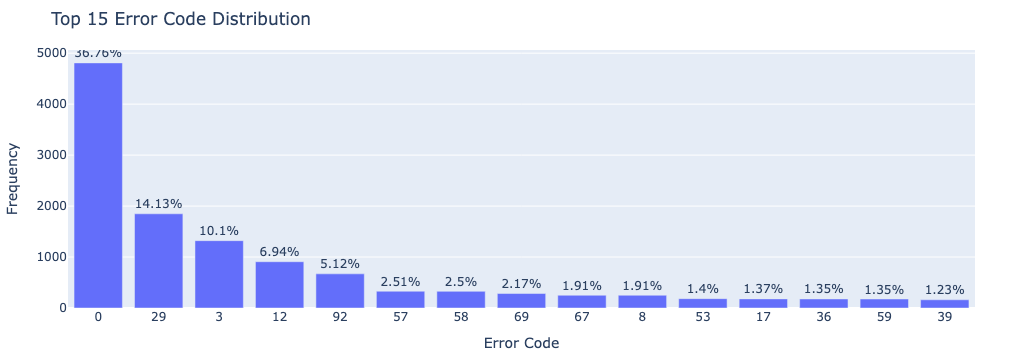

In [24]:
# VISUALIZATION: DISTRIBUTION TABLE


# Calculate Value Counts
distribution_table = df_exploded['CONTROLLER_ERROR_CODE'].value_counts().reset_index()
distribution_table.columns = ['Error Code', 'Count']

# Calculate Percentage 
total_errors = distribution_table['Count'].sum()
distribution_table['Percentage_Val'] = (distribution_table['Count'] / total_errors) * 100
distribution_table['Percentage_Str'] = distribution_table['Percentage_Val'].round(2).astype(str) + '%'

# Create Bar Chart
# showing the Top 15 errors to keep the chart readable 
fig_bar = px.bar(
    distribution_table.head(15),
    x='Error Code',
    y='Count',
    text='Percentage_Str', # Show percentage on top of bars
    title="Top 15 Error Code Distribution",
    labels={'Count': 'Frequency', 'Error Code': 'Error Code'}
)

# Update Layout for better readability
fig_bar.update_traces(textposition='outside') # Put text above the bars
fig_bar.update_layout(
    xaxis_type='category', # Ensure x-axis treats numbers as distinct categories
    xaxis={'categoryorder':'total descending'}, # Sort bars from high to low
    margin=dict(t=50, b=50, l=50, r=50)
)

fig_bar.show()



**Observations:**
1.Each feature has a different count (many null values) and varying range for different features. Hence the need for Data Cleaning and Normalisation in the preprocessing phase. 
2. The dataset is very imbalanced - used SMOTE to balance dataset

Top 10 Individual Error Codes: ['0', '29', '3', '12', '92']
Applying SMOTE balancing...


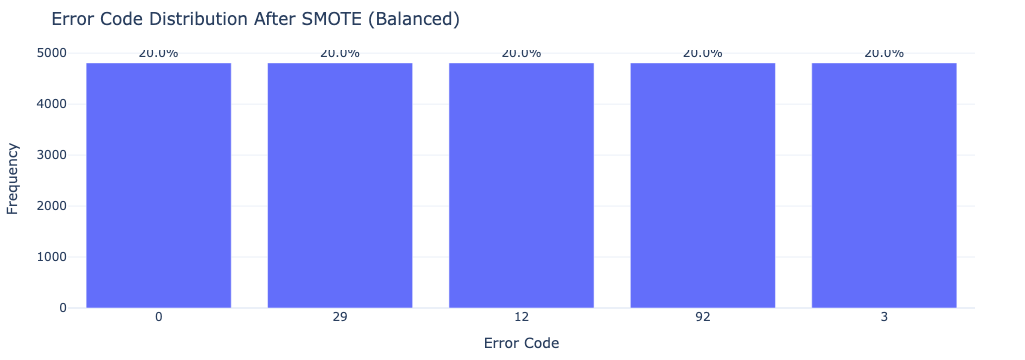

In [28]:

# FILTERING TOP 5 ERRORS

# Identify Top 5 most frequent error codes
top_5_errors = df_exploded['CONTROLLER_ERROR_CODE'].value_counts().nlargest(5).index.tolist()
print(f"Top 10 Individual Error Codes: {top_5_errors}")

# Filter dataset to only keep rows with these top 5 errors
df_filtered = df_exploded[df_exploded['CONTROLLER_ERROR_CODE'].isin(top_5_errors)].copy()

# Define Features (X) and Target (y) for training
X = df_filtered.drop(columns=['CONTROLLER_ERROR_CODE'])
y = df_filtered['CONTROLLER_ERROR_CODE']

# Balance Classes using SMOTE
print("Applying SMOTE balancing...")
smote = SMOTE(random_state=10, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X, y)


# VISUALIZATION: DISTRIBUTION AFTER SMOTE

# Create a temporary DataFrame for easy counting
df_resampled_dist = pd.DataFrame(y_resampled, columns=['CONTROLLER_ERROR_CODE'])

# Calculate Counts
resampled_counts = df_resampled_dist['CONTROLLER_ERROR_CODE'].value_counts().reset_index()
resampled_counts.columns = ['Error Code', 'Count']

# Calculate Percentages
total_resampled = resampled_counts['Count'].sum()
resampled_counts['Percentage'] = (resampled_counts['Count'] / total_resampled * 100).round(2).astype(str) + '%'

# Plot Bar Chart
fig_smote = px.bar(
    resampled_counts,
    x='Error Code',
    y='Count',
    text='Percentage',
    title="Error Code Distribution After SMOTE (Balanced)",
    labels={'Count': 'Frequency', 'Error Code': 'Error Code'},
    template='plotly_white'
)

fig_smote.update_traces(textposition='outside')
fig_smote.update_layout(
    xaxis_type='category',
    xaxis={'categoryorder':'total descending'},
    margin=dict(t=50, b=50, l=50, r=50)
)
fig_smote.show()




Applying SMOTE to balance classes...
Original shape: (24045, 34), Resampled shape: (24045, 26)


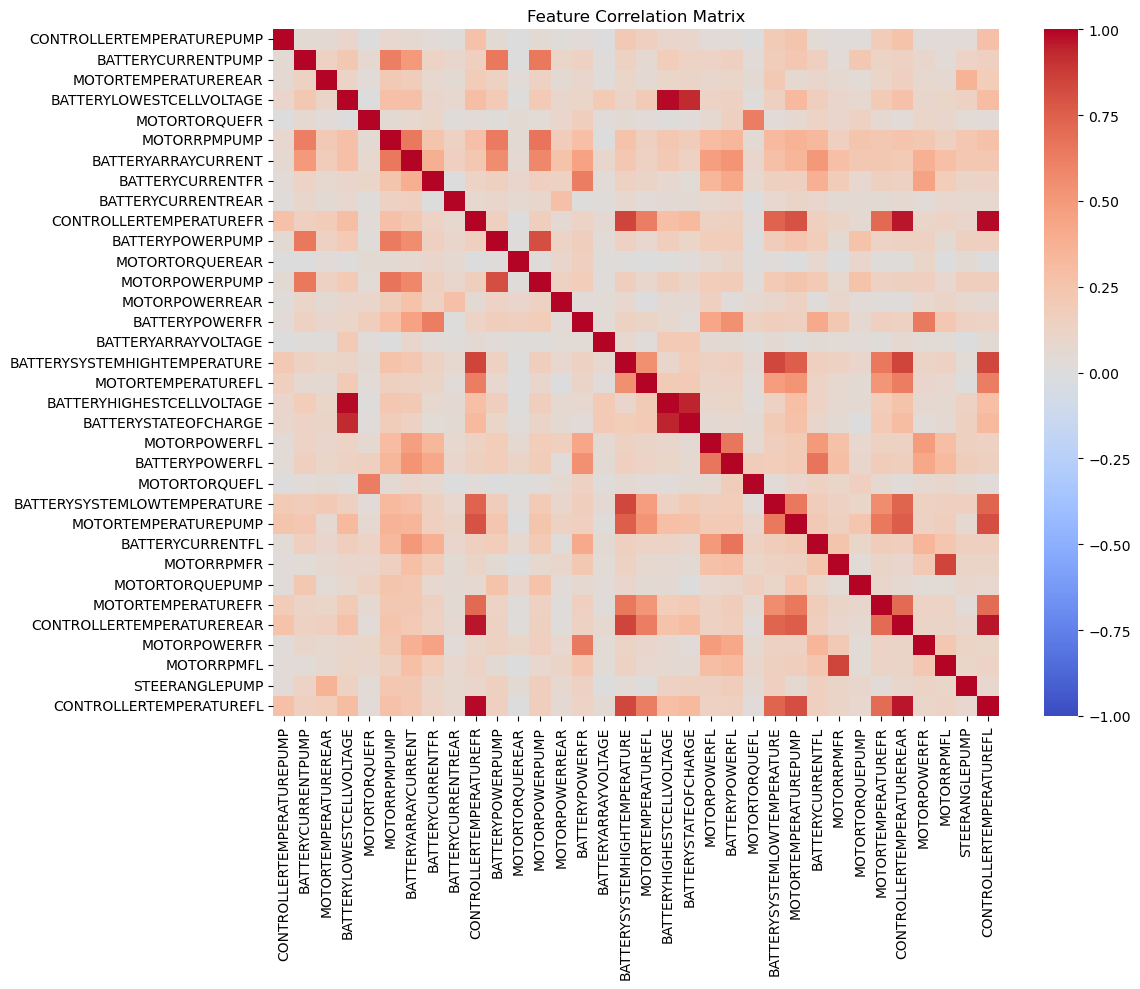

In [26]:

# CORRELATION MATRIX

# Geerating the Correlation Matrix
corr_matrix = X_resampled.corr().abs()

# Generate a correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')

# Correlation Reduction - Drop features > 80% correlated
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
X_reduced = X_resampled.drop(columns=to_drop)

# Rename Column Names
variable_description = {
    'CONTROLLERTEMPERATUREPUMP' : 'Controller Temp - Pump',
    'BATTERYCURRENTPUMP': 'Battery Current - Pump',
    'MOTORTEMPERATUREREAR': 'Motor Temperature',
    'BATTERYLOWESTCELLVOLTAGE': 'Lowest Cell Voltage',
    'MOTORTORQUEFR': 'Motor Torque - FR',
    'MOTORRPMPUMP': 'Motor RPM - Pump',
    'BATTERYARRAYCURRENT': 'Battery Array Current',
    'BATTERYCURRENTFR': 'Battery Current - FR',
    'BATTERYCURRENTREAR': 'Battery Current - Rear',
    'BATTERYPOWERPUMP': 'Battery Power - Pump',
    'MOTORTORQUEREAR': 'Motor Torque - Rear',
    'MOTORPOWERPUMP': 'Motor Power - Pump',
    'MOTORPOWERREAR': 'Motor Power - Rear',
    'BATTERYARRAYVOLTAGE': 'Battery Array Voltage',
    'BATTERYSTATEOFCHARGE': 'Battery SOC',
    'MOTORPOWERFL': 'Motor Power - FL',
    'MOTORTORQUEFL': 'Motor Torque - FL',
    'MOTORTORQUEPUMP': 'Motor Torque - Pump',
    'STEERANGLEPUMP': 'Steer Angle - Pump',
    'CONTROLLERTEMPERATUREFR': 'Controller Temperature - FR',
    'BATTERYSYSTEMHIGHTEMPERATURE': 'Battery System High Temperature',
    'MOTORTEMPERATUREFL': 'Motor Temperature - FL',
    'MOTORTEMPERATUREPUMP': 'Battery Temperature - Pump',
    'BATTERYCURRENTFL': 'Battery Current - FL',
    'MOTORRPMFR': 'Motor RPM - FR',
    'MOTORTEMPERATUREFR': 'Motor Temperature - FR',
    'MOTORPOWERFR': 'Motor Power - FR'
}
X_reduced = X_reduced.rename(columns=variable_description)

# Scaling X and y
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
le = LabelEncoder()
y_encoded = le.fit_transform(y_resampled)


print("Applying SMOTE to balance classes...")
print(f"Original shape: {X_resampled.shape}, Resampled shape: {X_reduced.shape}")

**MODELING**

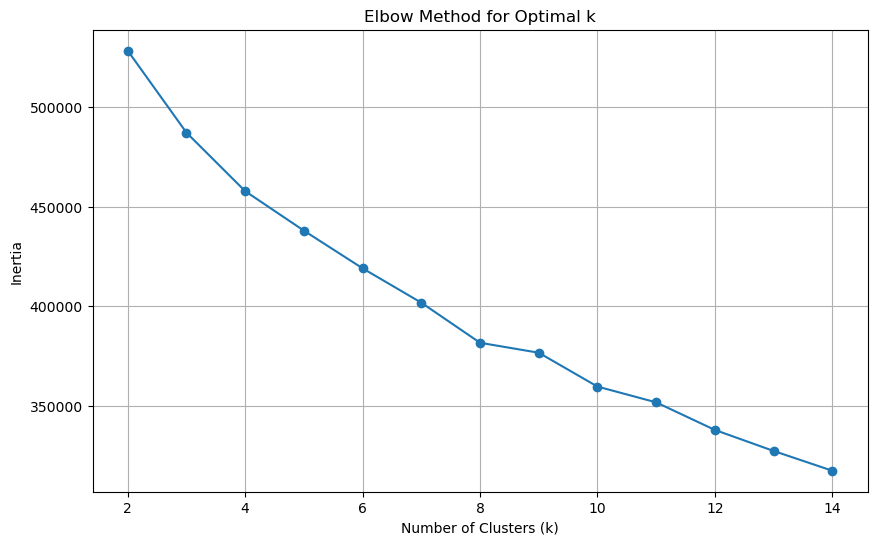

In [27]:
# Generate Elbow Chart (k=2 to 15)
inertia = []
k_range = range(2, 15)
for k_val in k_range:
    km = KMeans(n_clusters=k_val, random_state=10, n_init=5)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.savefig('elbow_plot_refined.png')


In [30]:
# Unsupervised Learning (Clustering)
# k=8 was selected based on the Elbow Method (point of diminishing returns).

k = 8 # k mean parameter selected based on the elbow curve

# K-Means: Partition data into k clusters by minimizing variance within clusters.
kmeans_labels = KMeans(n_clusters=k, random_state=10, n_init=10).fit_predict(X_scaled)
ari_kmeans = adjusted_rand_score(y_encoded, kmeans_labels)

# Agglomerative: Hierarchical clustering using Ward's method to minimize variance when merging.
agglo_labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
ari_agglo = adjusted_rand_score(y_encoded, agglo_labels)

# GMM: Probabilistic model 
gmm_labels = GaussianMixture(n_components=k, random_state=10).fit_predict(X_scaled)
ari_gmm = adjusted_rand_score(y_encoded, gmm_labels)

# Supervised (Random Forest)
# Split data: 70% for training the model, 30%
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=10)

# Random Forest: Ensemble of 100 decision trees.
rf = RandomForestClassifier(n_estimators=100, random_state=10)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred)

**PREPARE VISUALIZATION DATA**

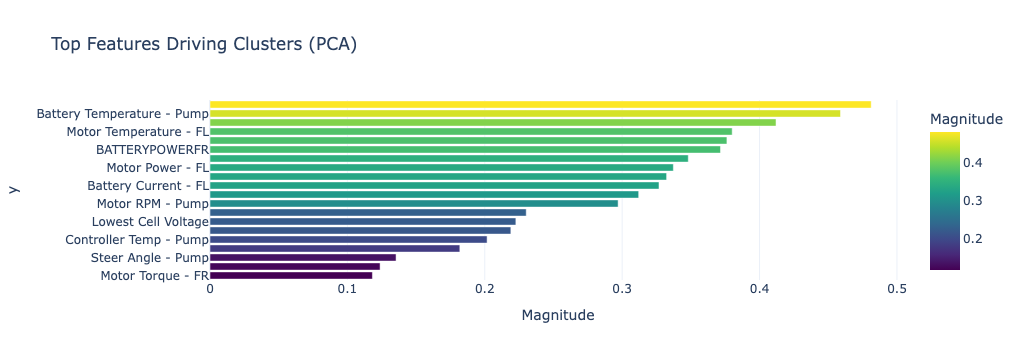

In [38]:
# PCA Projection
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled) # Fit PCA on the scaled data and transform it into the new 2D coordinates.

# Create a DataFrame for visualization to hold all necessary plotting data.
df_vis = pd.DataFrame(data=components, columns=['PC1', 'PC2'])

# Add the original class labels (decoded from numbers back to error names).
df_vis['Ground_Truth'] = le.inverse_transform(y_encoded)

# Add the predicted cluster labels from all three unsupervised models.
df_vis['KMeans_Label'] = kmeans_labels
df_vis['Agglo_Label'] = agglo_labels
df_vis['GMM_Label'] = gmm_labels

# Dynamic Feature Selection via PCA Loadings
# Identify which features drive the separation in PC1/PC2 space
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X_reduced.columns)
loadings['Magnitude'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
features_to_plot = loadings.nlargest(5, 'Magnitude').index.tolist()

# Add these features to df_vis for the Parallel Coordinates plot
for col in features_to_plot:
    df_vis[col] = X_reduced[col].values

# Extract feature importance scores from the trained Random Forest model.
importances = rf.feature_importances_
# Create a sorted DataFrame to rank features by their predictive power.
feature_importance_df = pd.DataFrame({'Feature': X_reduced.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Select the top 5 most critical features for the User Input form in the dashboard.
top_5_features = feature_importance_df.head(5)['Feature'].tolist()

# Calculate the mean of every feature to use as default values for missing inputs.
feature_means = X_reduced.mean()

# Create a horizontal bar chart showing the top 20 features driving the PCA spread.
fig_pca_imp = px.bar(
    loadings.nlargest(20, 'Magnitude'), 
    x='Magnitude', 
    y=loadings.nlargest(20, 'Magnitude').index, 
    orientation='h', 
    title="Top Features Driving Clusters (PCA)",
    template='plotly_white', 
    color='Magnitude', 
    color_continuous_scale='Viridis'
)
# Ensure the most important feature is at the top of the chart.
fig_pca_imp.update_layout(yaxis={'categoryorder':'total ascending'})

In [39]:
# Output Results
print(f"Top 5 Individual Error Codes: {list(top_5_errors)}")
print(f"\nClustering Results with k={k}:")
print(f"1. K-Means ARI: {ari_kmeans:.4f}")
print(f"2. Agglomerative ARI: {ari_agglo:.4f}")
print(f"3. GMM ARI: {ari_gmm:.4f}")

Top 5 Individual Error Codes: ['0', '29', '3', '12', '92']

Clustering Results with k=8:
1. K-Means ARI: 0.1244
2. Agglomerative ARI: 0.1438
3. GMM ARI: 0.1674


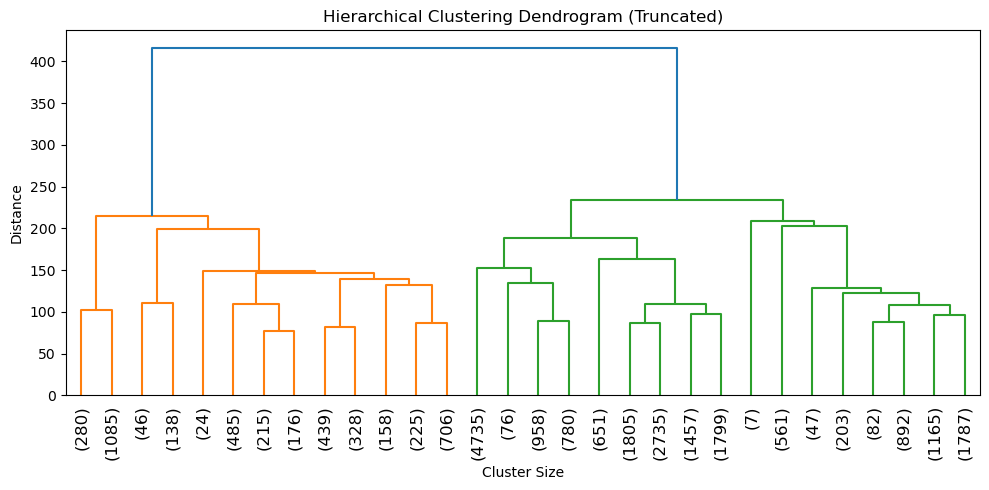

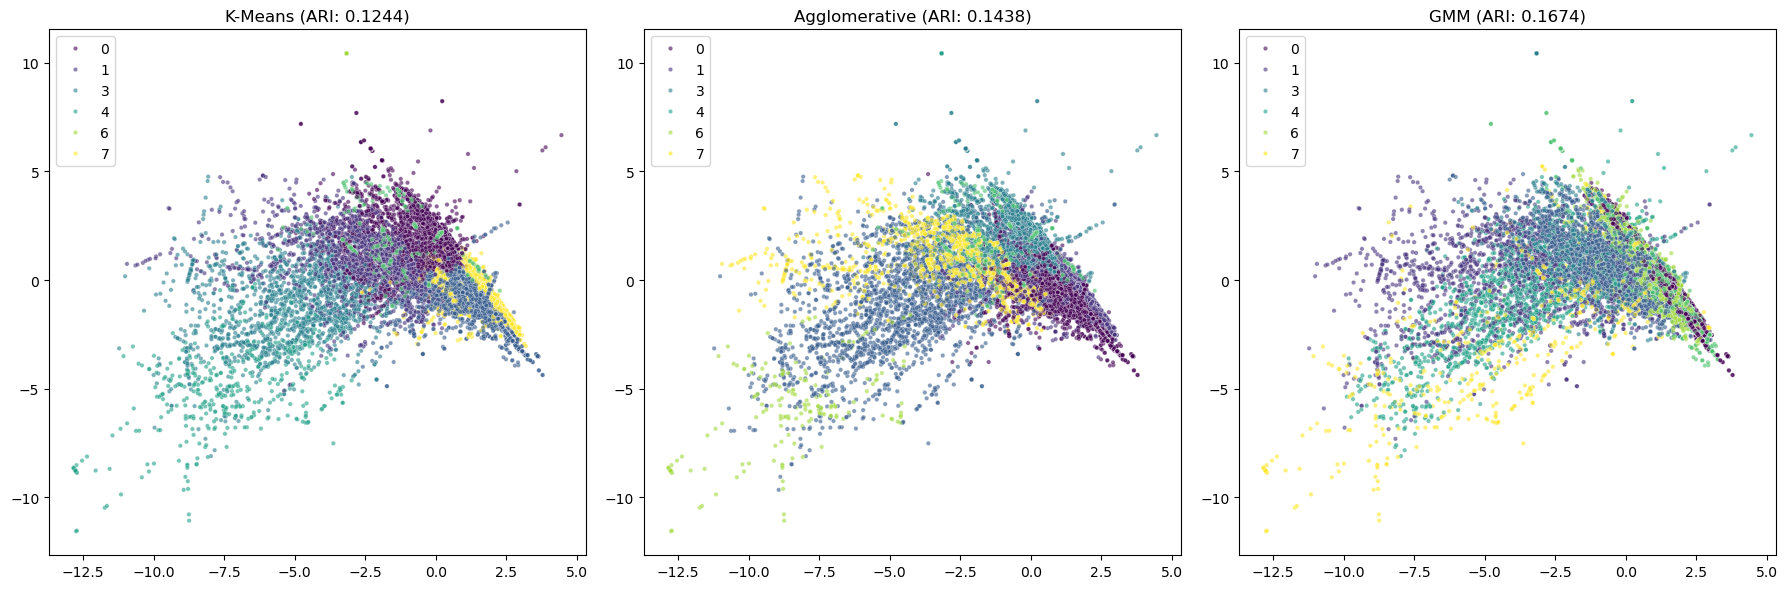

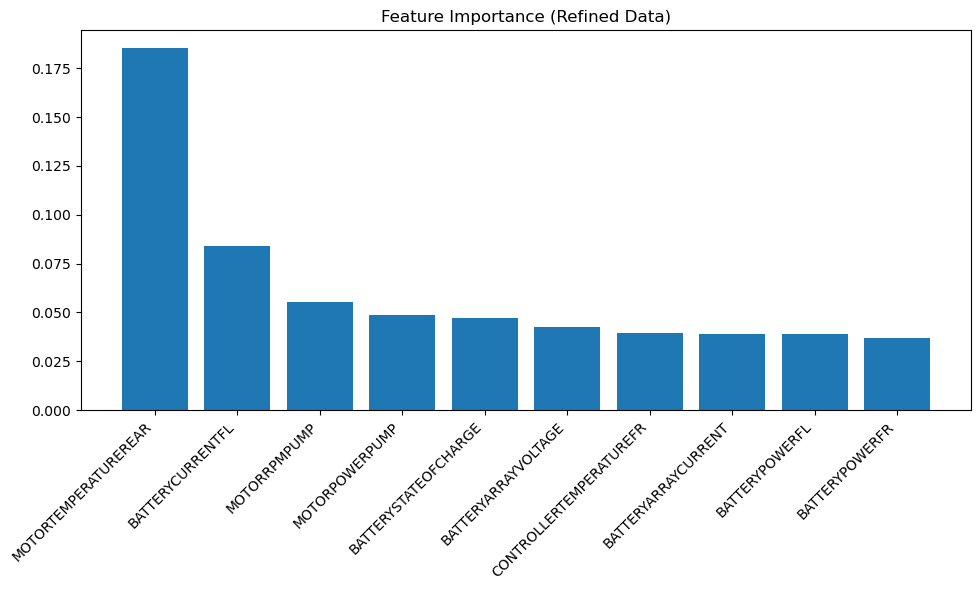

In [40]:
# Visualizations

# Dendrogram (Hierarchical Clustering)
# Initialize a figure for the dendrogram with a specified size.
plt.figure(figsize=(10, 5))
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Cluster Size') # X-axis represents the size of merged clusters
plt.ylabel('Distance') # Y-axis represents the distance (dissimilarity) at which merges occur

# Compute the linkage matrix 'Z' using Ward's method.
Z = linkage(X_scaled, method='ward')

# Plot the dendrogram using the computed linkage matrix.
# truncate_mode='lastp': Only show the last 'p' merged clusters to keep the plot readable.
# p=30: Show only the top 30 clusters/branches.
# show_contracted=False: Do not show contraction marks for hidden branches.
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=False)
plt.tight_layout()
plt.savefig('dendrogram_refined.png')

# Cluster Comparison
pca = PCA(n_components=12) #the top 12 pca makes up a significant portion of the PCA
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# K-Means
# Scatter plot of PC1 vs PC2, colored by K-Means cluster labels.
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', s=10, ax=axes[0], alpha=0.6)
axes[0].set_title(f'K-Means (ARI: {ari_kmeans:.4f})')

# Agglomerative
# Scatter plot of PC1 vs PC2, colored by Agglomerative cluster labels.
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agglo_labels, palette='viridis', s=10, ax=axes[1], alpha=0.6)
axes[1].set_title(f'Agglomerative (ARI: {ari_agglo:.4f})')

# GMM
# Scatter plot of PC1 vs PC2, colored by GMM cluster labels.
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_labels, palette='viridis', s=10, ax=axes[2], alpha=0.6)
axes[2].set_title(f'GMM (ARI: {ari_gmm:.4f})')

plt.tight_layout()
plt.savefig('clustering_comparison_refined.png')

# Extract feature importance scores from the trained Random Forest model.
importances = rf.feature_importances_

# Sort the feature indices based on importance scores in descending order.
indices = np.argsort(importances)[::-1]

# Get the names of the features
feature_names = X.columns

# Create a bar chart showing the importance of the top 10 features.
# importances[indices[:10]]: Get the importance scores of the top 10 features.
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Refined Data)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), feature_names[indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance_refined.png')

In [41]:
# Output Results
print("Refined Preprocessing Results:")
print(f"Top 10 Individual Error Codes: {list(top_5_errors)}")
print(f"K-Means ARI: {ari_kmeans:.4f}")
print(f"Agglomerative ARI: {ari_agglo:.4f}")
print(f"GMM ARI: {ari_gmm:.4f}")
print("\nRandom Forest Classification Report (Refined):")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

Refined Preprocessing Results:
Top 10 Individual Error Codes: ['0', '29', '3', '12', '92']
K-Means ARI: 0.1244
Agglomerative ARI: 0.1438
GMM ARI: 0.1674

Random Forest Classification Report (Refined):
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1436
          12       0.95      0.96      0.95      1446
          29       0.96      0.96      0.96      1427
           3       0.96      0.97      0.97      1430
          92       0.98      0.96      0.97      1475

    accuracy                           0.95      7214
   macro avg       0.95      0.95      0.95      7214
weighted avg       0.95      0.95      0.95      7214



In [42]:
# GENERATE STATIC IMAGE
plt.figure(figsize=(8, 5))

# Create a scatter plot to visualize the clusters in 2D PCA space.
# x, y: The principal components (PC1, PC2).
# hue: Color points based on the 'Agglo_Label' (Agglomerative Clustering results).
# palette: Color scheme ('viridis').
# s: Marker size (50).
# alpha: Transparency (0.7) to see overlapping points.
sns.scatterplot(x='PC1', y='PC2', hue='Agglo_Label', data=df_vis, palette='viridis', s=50, alpha=0.7)
plt.title('Static View: Agglomerative Clustering (k=8)')

# Add a grid to the background 
plt.grid(True, linestyle='--', alpha=0.5)
buf = io.BytesIO() 
plt.savefig(buf, format='png')
plt.close()
buf.seek(0)
encoded_image = base64.b64encode(buf.read()).decode('ascii')

In [44]:

# APP LAYOUT
# Load external CSS for a grid-based layout 
external_stylesheets = ['https://codepen.io/chriddyp/pen/bWLwgP.css']
app = Dash(__name__, external_stylesheets=external_stylesheets)


app.layout = html.Div([
    # Main Dashboard Title
    html.H2("ETMFL Predictive Maintenance Dashboard", style={'textAlign': 'center', 'color': '#2c3e50'}),

    # Split into tabs for better organization
    dcc.Tabs([
        # --- TAB 1: UNSUPERVISED ---
        # Tab for clustering results (K-Means, Agglomerative, GMM)
        dcc.Tab(label='Unsupervised Analysis', children=[
            html.Div([
                html.H4("Cluster Analysis", style={'textAlign': 'center', 'marginTop': '20px'}),

                # Static PCA Scatter Plot
                # Shows the "best" model's clustering result 
                html.Div([
                   html.Img(src='data:image/png;base64,{}'.format(encoded_image), style={'height': '300px', 'display': 'block', 'margin': 'auto', 'border': '1px solid #ddd', 'padding': '5px'})
                ], style={'marginBottom': '20px'}),

                # Controls - Algorithm Selector Dropdown
                # Allows the user to switch between clustering algorithms dynamically.
                html.Div([
                    html.Label("Select Algorithm:", style={'fontWeight': 'bold'}),
                    dcc.Dropdown(
                        id='algo-dropdown',
                        options=[
                            {'label': 'Agglomerative (Best)', 'value': 'Agglo_Label'},
                            {'label': 'K-Means', 'value': 'KMeans_Label'},
                            {'label': 'GMM', 'value': 'GMM_Label'}
                        ],
                        value='Agglo_Label',
                        clearable=False
                    )
                ], style={'width': '50%', 'margin': 'auto', 'marginBottom': '20px'}),

                # Graphs - Interactive Graphs
                # Left: Scatter Plot of clusters in 2D PCA space.
                # Right: Confusion Matrix comparing Clusters to True Error Codes.
                html.Div([
                    html.Div([dcc.Graph(id='cluster-scatter')], className='six columns'),
                    html.Div([dcc.Graph(id='confusion-heatmap')], className='six columns')
                ], className='row'),

                # Interactive Graphs 
                # Bottom: Parallel Coordinates plot to show the physical sensor profile of each cluster.
                html.Div([
                    html.H5("Operational Profile", style={'textAlign': 'center'}),
                    dcc.Graph(id='parallel-coords')
                ], className='row')
            ])
        ]),

        # --- TAB 2: SUPERVISED ---
        # Focuses on the Random Forest classification results
        dcc.Tab(label='Supervised Analysis', children=[
            html.Div([
                html.H4(f"Random Forest Performance (Accuracy: {rf_accuracy:.2%})", style={'textAlign': 'center', 'marginTop': '20px', 'color': '#2a9d8f'}),

                html.Div([
                    html.Div([
                        html.H5("Confusion Matrix", style={'textAlign': 'center'}),
                        dcc.Graph(id='rf-confusion-matrix')
                    ], className='six columns'),

                    html.Div([
                        html.H5("Top Feature Importance", style={'textAlign': 'center'}),
                        dcc.Graph(id='rf-feature-importance')
                    ], className='six columns')
                ], className='row'),

                html.Div([
                    html.H5("Classification Report", style={'textAlign': 'center'}),
                    html.Div(id='rf-metrics-table', style={'margin': '20px', 'textAlign': 'center'})
                ], className='row')
            ])
        ]),

        # --- TAB 3: PREDICTION TOOL ---
        # Allows users to input sensor data and get a real-time failure prediction
        dcc.Tab(label='Prediction Tool', children=[
            html.Div([
                html.H4("Real-time Failure Prediction", style={'textAlign': 'center', 'marginTop': '30px'}),
                html.P("Enter sensor values below. Unspecified sensors will use average values.", style={'textAlign': 'center', 'color': '#7f8c8d'}),

                # Dynamic Input Fields for Top 5 Features
                # Automatically generates input boxes for the Top 5 most important features.
                # Default value is the mean from the training set.
                html.Div([
                    html.Div([
                        html.Label(feat, style={'fontWeight': 'bold'}),
                        dcc.Input(
                            id={'type': 'pred-input', 'index': feat},
                            type='number',
                            placeholder=f"Avg: {feature_means[feat]:.2f}",
                            value=round(feature_means[feat], 2), # Default to mean
                            style={'width': '100%'}
                        )
                    ], className='two columns') for feat in top_5_features
                ], className='row', style={'padding': '20px', 'display': 'flex', 'justifyContent': 'center'}),
                
                # Predict Button
                html.Div([
                    html.Button('Predict Failure', id='btn-predict', n_clicks=0, className='button-primary', style={'fontSize': '18px'})
                ], style={'textAlign': 'center', 'marginTop': '20px'}),

                # Prediction Output Result
                html.Div(id='prediction-output', style={'textAlign': 'center', 'marginTop': '30px', 'padding': '20px'})

            ], style={'backgroundColor': '#f4f6f7', 'padding': '40px', 'borderRadius': '10px', 'margin': '20px'})
        ])
    ])
])

# CALLBACKS (INTERACTIVITY LOGIC)

# Callback 1: Update Unsupervised Graphs
# Triggered when 'algo-dropdown' changes. Updates Scatter, Heatmap, and Parallel Coords.
@app.callback(
    [Output('cluster-scatter', 'figure', allow_duplicate=True),
     Output('confusion-heatmap', 'figure'),
     Output('parallel-coords', 'figure')],
    [Input('algo-dropdown', 'value')],
    prevent_initial_call='initial_duplicate'
)
def update_unsupervised(selected_algo):
    # Scatter Plot: Colors points by the selected algorithm's labels
    fig_scatter = px.scatter(df_vis, x='PC1', y='PC2', color=df_vis[selected_algo].astype(str), 
                             title=f"Cluster Separation - {selected_algo}", template='plotly_white')

    # Heatmap: Shows agreement between clusters and ground truth error codes
    conf_matrix = pd.crosstab(df_vis['Ground_Truth'], df_vis[selected_algo])
    fig_heatmap = go.Figure(data=go.Heatmap(z=conf_matrix.values, x=conf_matrix.columns, y=conf_matrix.index, colorscale='Blues'))
    fig_heatmap.update_layout(title="Confusion Matrix", xaxis_title="Cluster", yaxis_title="True Error")

    # Parallel Coords: Plots the mean sensor profile for each cluster
    cluster_profile = df_vis.groupby(selected_algo)[features_to_plot].mean().reset_index()
    fig_parcoords = px.parallel_coordinates(cluster_profile, color=selected_algo, dimensions=features_to_plot, color_continuous_scale=px.colors.diverging.Tealrose)
        
    return fig_scatter, fig_heatmap, fig_parcoords

# Callback 2: Update Supervised Graphs
# Updates the Random Forest metrics when the dropdown changes.
@app.callback(
    [Output('rf-confusion-matrix', 'figure'),
     Output('rf-feature-importance', 'figure'),
     Output('rf-metrics-table', 'children')],
    [Input('algo-dropdown', 'value')]
)
def update_supervised(_):
    # Confusion Matrix for Random Forest
    cm = confusion_matrix(y_test, y_pred)
    labels = le.inverse_transform(sorted(list(set(y_test))))
    fig_cm = go.Figure(data=go.Heatmap(z=cm, x=labels, y=labels, colorscale='Greens', text=cm, texttemplate="%{text}"))
    fig_cm.update_layout(title="Confusion Matrix (Supervised)", xaxis_title="Predicted", yaxis_title="Actual")

    # Feature Importance Bar Chart
    fig_imp = px.bar(feature_importance_df.head(10), x='Importance', y='Feature', orientation='h', title="Random Forest Feature Importance", template='plotly_white')
    fig_imp.update_layout(yaxis={'categoryorder':'total ascending'})

    # Classification Report Table
    report = classification_report(y_test, y_pred, target_names=[str(l) for l in labels], output_dict=True)
    rows = [html.Tr([html.Th("Class"), html.Th("Precision"), html.Th("Recall"), html.Th("F1-Score")])]
    for label, metrics in report.items():
        if isinstance(metrics, dict):
            rows.append(html.Tr([
                html.Td(label),
                html.Td(f"{metrics['precision']:.2f}"),
                html.Td(f"{metrics['recall']:.2f}"),
                html.Td(f"{metrics['f1-score']:.2f}")
            ]))
    return fig_cm, fig_imp, html.Table(rows, className='table', style={'width': '80%', 'marginLeft': 'auto', 'marginRight': 'auto'})

# Callback 3: Prediction Logic
# Takes user inputs, imputes missing values with means, scales data, and predicts using the trained Random Forest model.
@app.callback(
    Output('prediction-output', 'children'),
    [Input('btn-predict', 'n_clicks')],
    [State({'type': 'pred-input', 'index': ALL}, 'value'),
     State({'type': 'pred-input', 'index': ALL}, 'id')]
)
def predict_failure(n_clicks, input_values, input_ids):
    if n_clicks == 0: return ""

    # Construct input vector (starting with means)
    input_vector = feature_means.copy()
    for val, id_dict in zip(input_values, input_ids):
        if val is not None:
            input_vector[id_dict['index']] = val

    # Scale and Predict
    input_df = pd.DataFrame([input_vector], columns=X_reduced.columns)
    input_scaled = scaler.transform(input_df)
    
    prediction_code = rf.predict(input_scaled)[0]
    prediction_prob = np.max(rf.predict_proba(input_scaled))
    decoded_error = le.inverse_transform([prediction_code])[0]

    # Return Result
    return html.Div([
        html.H3(f"Predicted Error Code: {decoded_error}", style={'color': '#e74c3c', 'fontWeight': 'bold'}),
        html.H5(f"Confidence: {prediction_prob:.2%}", style={'color': '#7f8c8d'})
    ])

if __name__ == '__main__':
    print("Dash is running. Open this link: http://127.0.0.1:8055/")
    app.run(debug=False, host='0.0.0.0', port=8055)

Dash is running. Open this link: http://127.0.0.1:8055/
